In [21]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.manifold import TSNE
from sklearn.neighbors import NearestNeighbors
import warnings
warnings.filterwarnings('ignore')
#------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

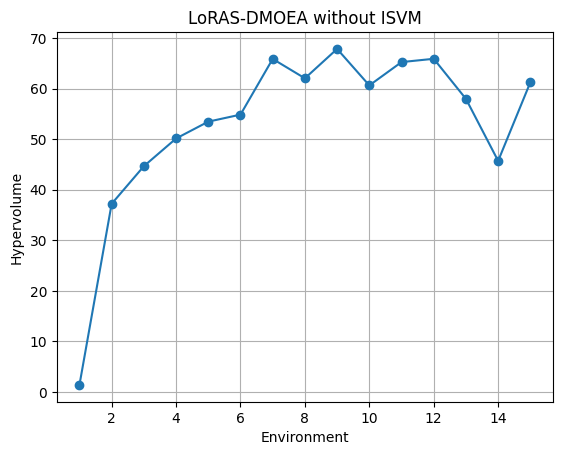

In [68]:
class LoRAS:
    def __init__(self, k=8, num_shadow_points=10, sigma=0.005, 
                 num_aff_comb=5, random_state=42):
        self.k = k
        self.num_shadow_points = num_shadow_points
        self.sigma = sigma
        self.num_aff_comb = num_aff_comb
        np.random.seed(random_state)

    def _generate_shadowsamples(self, point, num_shadows):
        shadows = []
        for _ in range(num_shadows):
            noise = np.random.normal(0, self.sigma, point.shape)
            shadows.append(point + noise)
        return np.array(shadows)

    def _affine_combination(self, points, num_combinations):
        synthetic = []
        for _ in range(num_combinations):
            idx = np.random.choice(len(points), 
                                   size=min(self.num_aff_comb, len(points)), 
                                   replace=False)
            pts = points[idx]
            w = np.random.random(len(pts))
            w /= w.sum()
            synthetic.append((pts * w[:,None]).sum(axis=0))
        return np.array(synthetic)

    def fit_resample(self, minority_points, num_generated):
        if len(minority_points)==0:
            return np.empty((0, minority_points.shape[1]))
        nbrs = None
        if len(minority_points)>self.k:
            nbrs = NearestNeighbors(n_neighbors=self.k+1).fit(minority_points)
        synthetic = []
        for pt in minority_points:
            if nbrs:
                d,i = nbrs.kneighbors([pt])
                neigh = minority_points[i[0][1:]]
            else:
                neigh = minority_points
            shadows = np.vstack([self._generate_shadowsamples(n, self.num_shadow_points)
                                 for n in neigh])
            combos = max(1, num_generated//len(minority_points))
            syn = self._affine_combination(shadows, combos)
            synthetic.extend(syn)
        return np.array(synthetic[:num_generated])

class LoRAS_MOEA:
    def __init__(self, pop_size=100, random_state=42):
        self.pop_size = pop_size
        self.loras = LoRAS(random_state=random_state)

    def _evaluate(self, pop, t):
        n = pop.shape[1]
        shift = 0.5 * np.sin(np.pi * t / 20)
    
        # f1: distance to time-varying target
        f1 = np.sum((pop - shift) ** 2, axis=1)
    
        # f2: distance to another target + constraint penalty
        f2 = np.sum((pop - (1 - shift)) ** 2, axis=1) + \
             10 * np.maximum(0, np.sum(pop, axis=1) - 1.5)
    
        # two-objective minimization
        return np.vstack([f1, f2]).T
        
    def _evaluate_dynamic_shifted_rastrigin(self, pop, t):
        shift1 = t * 0.05
        shift2 = 1 - t * 0.05

        f1 = np.sum((pop - shift1) ** 2, axis=1)  # Sphere function with shift
        A = 10
        n = pop.shape[1]
        z = pop - shift2
        f2 = A * n + np.sum(z ** 2 - A * np.cos(2 * np.pi * z), axis=1)  # Rastrigin shifted
        return np.vstack([f1, f2]).T
    
    def _evaluate_dynamic_time_linkage(self, pop, t, prev_pop_mean=None):
        n = pop.shape[1]
        shift = 0.5 * np.sin(np.pi * t / 20)
    
        # Time-linkage: bias from previous environment
        if prev_pop_mean is not None:
            linkage = 0.1 * np.sum((pop - prev_pop_mean) ** 2, axis=1)
        else:
            linkage = 0.0
    
        f1 = np.sum((pop - shift) ** 2, axis=1) + linkage
        f2 = np.sum((pop - (1 - shift)) ** 2, axis=1) + linkage
    
        # Time-varying box constraint: upper bound oscillates
        upper = 0.8 + 0.2 * np.sin(np.pi * t / 10)
        violation = np.sum(np.maximum(0, pop - upper), axis=1)
        penalty = 15 * violation
    
        f1 += penalty
        f2 += penalty
        return np.vstack([f1, f2]).T
    



    
    def _evaluate_dynamic_dtlz2(self, pop, t):
        # t modifies the shape of Pareto front over time using a sinusoid
        n = pop.shape[1]
        shift = 0.2 * np.sin(np.pi * t / 15)

        g = np.sum((pop[:, :-1] - shift) ** 2, axis=1)
        theta = (np.pi / 2) * pop[:, -1]

        f1 = (1 + g) * np.cos(theta)
        f2 = (1 + g) * np.sin(theta)
        return np.vstack([f1, f2]).T
        
    def _evaluate_dynamic_history_dtlz2(self, pop, t, prev_pop_mean=None):
        # pop: (N, n), n >= 2
        n = pop.shape[1]
    
        # Time-varying shift on tail variables
        base_shift = 0.2 * np.sin(np.pi * t / 18.0)
        z = pop[:, 1:] - base_shift
    
        g_base = np.sum((z - 0.5) ** 2, axis=1)
    
        # History bias in g using previous mean of tail variables
        if prev_pop_mean is not None:
            tail_mean = prev_pop_mean[1:]
            history = np.sum((z - tail_mean) ** 2, axis=1)
        else:
            history = 0.0
    
        g = g_base + 0.2 * history
    
        theta = 0.5 * np.pi * pop[:, 0]
    
        f1 = (1.0 + g) * np.cos(theta)
        f2 = (1.0 + g) * np.sin(theta)
    
        # Dynamic upper bound on all variables
        upper = 0.9 + 0.1 * np.sin(np.pi * t / 12.0)
        viol = np.sum(np.maximum(0.0, pop - upper), axis=1)
        penalty = 20.0 * viol
    
        f1 += penalty
        f2 += penalty
        return np.vstack([f1, f2]).T
        
    def _evaluate_dynamic_velocity_linkage(self, pop, t, prev_pop_mean=None, prev_prev_pop_mean=None):
        n = pop.shape[1]
        shift = 0.3 + 0.3 * np.sin(np.pi * t / 30)
    
        # Velocity of the population mean across two previous environments
        if prev_pop_mean is not None and prev_prev_pop_mean is not None:
            vel = prev_pop_mean - prev_prev_pop_mean
            vel_term = 0.1 * np.sum((pop - (prev_pop_mean + vel)) ** 2, axis=1)
        else:
            vel_term = 0.0
    
        # Moving quadratic objectives
        f1 = np.sum((pop - shift) ** 2, axis=1) + vel_term
        f2 = np.sum((pop - (1.0 - shift)) ** 2, axis=1) + vel_term
    
        # Simple sum constraint (no oscillation here)
        viol = np.maximum(0.0, np.sum(pop, axis=1) - 1.6)
        penalty = 15.0 * viol
    
        f1 += penalty
        f2 += penalty
        return np.vstack([f1, f2]).T

    def _pareto(self, pop, obj):
        n = len(pop)
        mask = np.ones(n, bool)
        for i in range(n):
            for j in range(n):
                if i!=j and np.all(obj[j]<=obj[i]) and np.any(obj[j]<obj[i]):
                    mask[i]=False
                    break
        return pop[mask], obj[mask]

    def optimize(self, bounds, n_env=10, n_gen=50, minority_samples=None):
        # use oversampled positives as initial population
        if minority_samples is None or len(minority_samples)==0:
            population = np.random.uniform(bounds[:,0], bounds[:,1],
                                           (self.pop_size, bounds.shape[0]))
        else:
            oversampled = self.loras.fit_resample(minority_samples, self.pop_size)
            population = np.vstack([minority_samples, oversampled])[:self.pop_size]
        perf_hist = []
        for env in range(n_env):
            best_objs = []
            for gen in range(n_gen):
                obj = self._evaluate_dynamic_history_dtlz2(population, env)
                pop_p, obj_p = self._pareto(population, obj)
                best_objs.append([obj_p[:,0].min(), obj_p[:,1].min()])
                # mutation
                for i in range(len(population)):
                    if np.random.rand()<0.1:
                        m = np.random.normal(0,0.1, population.shape[1])
                        population[i] = np.clip(population[i]+m, 
                                                bounds[:,0], bounds[:,1])
            # record hypervolume = f1_min * f2_min
            last = best_objs[-1]
            perf_hist.append(last[0]*last[1])
            # for next env, treat current Pareto as new population
            population = pop_p.copy()
            # if too small, refill randomly
            if len(population)<self.pop_size:
                extra = np.random.uniform(bounds[:,0], bounds[:,1],
                                          (self.pop_size-len(population),
                                           bounds.shape[0]))
                population = np.vstack([population, extra])
        return perf_hist
   
# Example usage
if __name__=='__main__':
    # Suppose minority class data X_min (shape [n_min, dim])
    # Load or define X_min here
    # e.g., X_min = np.random.uniform(-2,2,(10,2))
   
    X_min = np.random.uniform(-2,2,(10,2))
    bounds = np.array([[-2,2],[-2,2]])
    moea = LoRAS_MOEA(pop_size=100)
    perf = moea.optimize(bounds, n_env=15, n_gen=30, minority_samples=X_min)
    plt.plot(range(1,16), perf, marker='o')
    plt.xlabel('Environment')
    plt.ylabel('Hypervolume')
    plt.title('LoRAS-DMOEA without ISVM')
    plt.grid(True)
    plt.show()
    


In [69]:
class MOEA_Random:
    def __init__(self, pop_size=100, random_state=42):
        self.pop_size = pop_size
        self.loras = LoRAS(random_state=random_state)

    def _evaluate(self, pop, t):
        n = pop.shape[1]
        shift = 0.5 * np.sin(np.pi * t / 20)
    
        # f1: distance to time-varying target
        f1 = np.sum((pop - shift) ** 2, axis=1)
    
        # f2: distance to another target + constraint penalty
        f2 = np.sum((pop - (1 - shift)) ** 2, axis=1) + \
             10 * np.maximum(0, np.sum(pop, axis=1) - 1.5)
    
        # two-objective minimization
        return np.vstack([f1, f2]).T


    # def _evaluate(self, pop, t):
        
    #     n = pop.shape[1]
    #     shift = 0.5 * np.sin(np.pi * t / 20)

    #     # Add more realistic multi-objective functions
    #     f1 = np.sum((pop - shift) ** 2, axis=1)
    #     f2 = np.sum((pop - (1 - shift)) ** 2, axis=1) + \
    #          10 * np.maximum(0, np.sum(pop, axis=1) - 1.5)

    #     # Add convergence and diversity metrics
    #     f3 = np.var(pop, axis=1)  # Diversity objective
    #     return np.vstack([f1, f2, f3]).T
        
    #     # f1 = np.sum((pop - t*0.1)**2, axis=1)
    #     # f2 = np.sum((pop - 1 + t*0.1)**2, axis=1)
    #     # return np.vstack([f1,f2]).T
        
    def _evaluate_dynamic_shifted_rastrigin(self, pop, t):
        shift1 = t * 0.05
        shift2 = 1 - t * 0.05

        f1 = np.sum((pop - shift1) ** 2, axis=1)  # Sphere function with shift
        A = 10
        n = pop.shape[1]
        z = pop - shift2
        f2 = A * n + np.sum(z ** 2 - A * np.cos(2 * np.pi * z), axis=1)  # Rastrigin shifted
        return np.vstack([f1, f2]).T
    
    def _evaluate_dynamic_time_linkage(self, pop, t, prev_pop_mean=None):
        n = pop.shape[1]
        shift = 0.5 * np.sin(np.pi * t / 20)
    
        # Time-linkage: bias from previous environment
        if prev_pop_mean is not None:
            linkage = 0.1 * np.sum((pop - prev_pop_mean) ** 2, axis=1)
        else:
            linkage = 0.0
    
        f1 = np.sum((pop - shift) ** 2, axis=1) + linkage
        f2 = np.sum((pop - (1 - shift)) ** 2, axis=1) + linkage
    
        # Time-varying box constraint: upper bound oscillates
        upper = 0.8 + 0.2 * np.sin(np.pi * t / 10)
        violation = np.sum(np.maximum(0, pop - upper), axis=1)
        penalty = 15 * violation
    
        f1 += penalty
        f2 += penalty
        return np.vstack([f1, f2]).T

    
    def _evaluate_dynamic_dtlz2(self, pop, t):
        # t modifies the shape of Pareto front over time using a sinusoid
        n = pop.shape[1]
        shift = 0.2 * np.sin(np.pi * t / 15)

        g = np.sum((pop[:, :-1] - shift) ** 2, axis=1)
        theta = (np.pi / 2) * pop[:, -1]

        f1 = (1 + g) * np.cos(theta)
        f2 = (1 + g) * np.sin(theta)
        return np.vstack([f1, f2]).T
        
    def _evaluate_dynamic_history_dtlz2(self, pop, t, prev_pop_mean=None):
        # pop: (N, n), n >= 2
        n = pop.shape[1]
    
        # Time-varying shift on tail variables
        base_shift = 0.2 * np.sin(np.pi * t / 18.0)
        z = pop[:, 1:] - base_shift
    
        g_base = np.sum((z - 0.5) ** 2, axis=1)
    
        # History bias in g using previous mean of tail variables
        if prev_pop_mean is not None:
            tail_mean = prev_pop_mean[1:]
            history = np.sum((z - tail_mean) ** 2, axis=1)
        else:
            history = 0.0
    
        g = g_base + 0.2 * history
    
        theta = 0.5 * np.pi * pop[:, 0]
    
        f1 = (1.0 + g) * np.cos(theta)
        f2 = (1.0 + g) * np.sin(theta)
    
        # Dynamic upper bound on all variables
        upper = 0.9 + 0.1 * np.sin(np.pi * t / 12.0)
        viol = np.sum(np.maximum(0.0, pop - upper), axis=1)
        penalty = 20.0 * viol
    
        f1 += penalty
        f2 += penalty
        return np.vstack([f1, f2]).T

    def _evaluate_dynamic_velocity_linkage(self, pop, t, prev_pop_mean=None, prev_prev_pop_mean=None):
        n = pop.shape[1]
        shift = 0.3 + 0.3 * np.sin(np.pi * t / 30)
    
        # Velocity of the population mean across two previous environments
        if prev_pop_mean is not None and prev_prev_pop_mean is not None:
            vel = prev_pop_mean - prev_prev_pop_mean
            vel_term = 0.1 * np.sum((pop - (prev_pop_mean + vel)) ** 2, axis=1)
        else:
            vel_term = 0.0
    
        # Moving quadratic objectives
        f1 = np.sum((pop - shift) ** 2, axis=1) + vel_term
        f2 = np.sum((pop - (1.0 - shift)) ** 2, axis=1) + vel_term
    
        # Simple sum constraint (no oscillation here)
        viol = np.maximum(0.0, np.sum(pop, axis=1) - 1.6)
        penalty = 15.0 * viol
    
        f1 += penalty
        f2 += penalty
        return np.vstack([f1, f2]).T




    def _pareto(self, pop, obj):
        n = len(pop)
        mask = np.ones(n, bool)
        for i in range(n):
            for j in range(n):
                if i!=j and np.all(obj[j]<=obj[i]) and np.any(obj[j]<obj[i]):
                    mask[i]=False
                    break
        return pop[mask], obj[mask]

    def optimize(self, bounds, n_env=10, n_gen=50, minority_samples=None):
        # use oversampled positives as initial population
        
        population = np.random.uniform(bounds[:,0], bounds[:,1],
                                           (self.pop_size, bounds.shape[0]))
       
        perf_hist = []
        for env in range(n_env):
            best_objs = []
            for gen in range(n_gen):
                obj = self._evaluate_dynamic_history_dtlz2(population, env)
                pop_p, obj_p = self._pareto(population, obj)
                best_objs.append([obj_p[:,0].min(), obj_p[:,1].min()])
                # mutation
                for i in range(len(population)):
                    if np.random.rand()<0.1:
                        m = np.random.normal(0,0.1, population.shape[1])
                        population[i] = np.clip(population[i]+m, 
                                                bounds[:,0], bounds[:,1])
            # record hypervolume = f1_min * f2_min
            last = best_objs[-1]
            perf_hist.append(last[0]*last[1])
            # for next env, treat current Pareto as new population
            population = pop_p.copy()
            # if too small, refill randomly
            if len(population)<self.pop_size:
                extra = np.random.uniform(bounds[:,0], bounds[:,1],
                                          (self.pop_size-len(population),
                                           bounds.shape[0]))
                population = np.vstack([population, extra])
        return perf_hist
   

Running LoRAS-MOEA ...
Th LoRAS_MOEA
[ 9.52524538 29.23745506 38.88829496 44.30885625 49.92966529 51.07320078
 53.68189426 56.76625892 57.82676945 59.51077105 60.28883162 58.65029671
 54.49837018 53.6159634  50.91770439]
RANDOM_MOEA
[35.18606162 43.37684025 51.05069191 54.53045637 55.96065514 55.54476223
 57.16775874 57.65742795 57.63161615 59.6432909  61.87730748 61.11755264
 57.14983014 53.44892446 54.55027839]


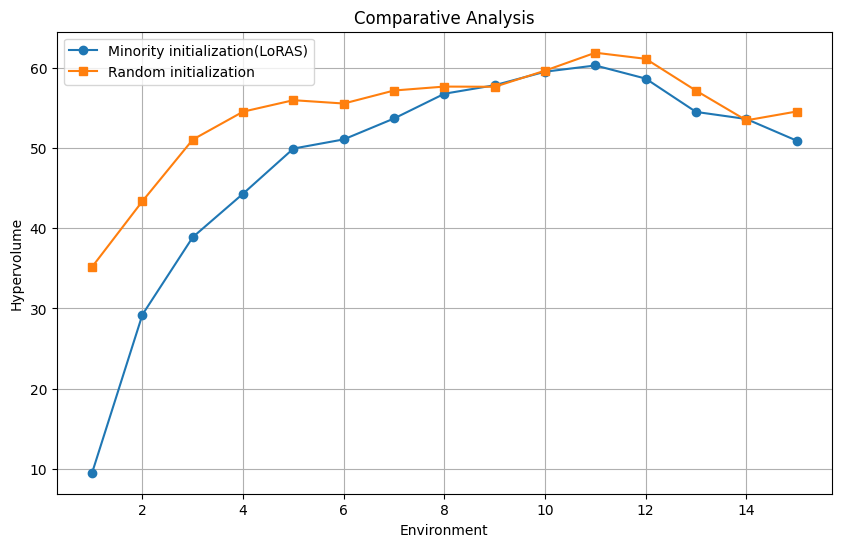

Average performance over 15 environments:
LoRAS MOEA: 48.58131
MOEA RANDOM: 54.39290


In [70]:

def comparative_analysis():
    bounds = np.array([[-2, 2], [-2, 2]])
    runs = 10
    n_env = 15
    n_gen = 30
    minority_samples = np.random.uniform(-2, 2, (10, 2))  # example minority samples
    
    loras_performances = []
    random_performances = []
    
    print("Running LoRAS-MOEA ...")
    for seed in range(runs):
        moea_loras = LoRAS_MOEA(pop_size=100, random_state=seed)
        perf = moea_loras.optimize(bounds, n_env=n_env, n_gen=n_gen,
                                   minority_samples=minority_samples)
        loras_performances.append(perf)
        
        
    for seed in range(runs):
        moea_loras_random = MOEA_Random(pop_size=100, random_state=seed)
        perf = moea_loras_random.optimize(bounds, n_env=n_env, n_gen=n_gen)
        random_performances.append(perf)
    
    
    loras_mean = np.mean(loras_performances, axis=0)
    random_mean = np.mean(random_performances, axis=0)

    print("Th LoRAS_MOEA")
    print(loras_mean)
    print("RANDOM_MOEA")
    print(random_mean)
    
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, n_env + 1), loras_mean, marker='o', label='Minority initialization(LoRAS)')
    plt.plot(range(1, n_env + 1), random_mean, marker='s', label='Random initialization')
    plt.xlabel('Environment')
    #plt.ylabel('Hypervolume (min f1 * min f2)')
    plt.ylabel('Hypervolume')
    plt.title('Comparative Analysis')
    plt.grid(True)
    plt.legend()
    plt.show()
    
    print(f"Average performance over {n_env} environments:")
    print(f"LoRAS MOEA: {loras_mean.mean():.5f}")
    print(f"MOEA RANDOM: {random_mean.mean():.5f}")

if __name__ == '__main__':
    comparative_analysis()